# Modelo de Regresión Logística Múltiple
**Variable respuesta:** `MC_CESD_DEPRIMIDO_21` (depresión, escala CES-D)

**Fuente:** ECENASEM 2021 (Evaluación Cognitiva, ENASEM)

## 1. Librerías

In [1]:
import re
import textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Carga de datos

In [2]:
# Ajusta la ruta según donde tengas el archivo
ruta_csv = "conjunto_de_datos_mex_cog_2021_evaluacion_cognitiva_ecenasem_2021.csv"

datos_crudos = pd.read_csv(ruta_csv, dtype=str)
datos_crudos.head()

,CUNICAH,NP,SUBHOG_MXCOG_21,MC_TIPENT_COGNITIVO_21,INT_DATE_MXCOG_21,EST_DIS_MXCOG_21,UPM_DIS_MXCOG_21,TAM_LOC_MXCOG_21,FACTOR_MXCOG_21,AGE_MXCOG_21,SEX_MXCOG_21,MC_PRE_A_21,MC_FILTRO_C_21,MC_P1A_1_21,MC_P1A_2_21,MC_P1A_3_21,MC_P2_21,MC_P2A_21,MC_P3_1_21,MC_P3_2_21,MC_P3A_1_21,MC_P3A_2_21,MC_P4_1_21,MC_P4_2_21,MC_P4_3_21,MC_P5_1_21,MC_P5_2_21,MC_P5_3_21,MC_P6_1_21,MC_P6_2_21,MC_P6_3_21,MC_P6_4_21,MC_P6_5_21,MC_P7_1_21,MC_P7_2_21,MC_P7_3_21,MC_P7_4_21,MC_P7_5_21,MC_P8_1_21,MC_P8_2_21,MC_P8_3_21,MC_P9_1_21,MC_P9_2_21,MC_P9_3_21,MC_FILTRO_D_21,MC_P10_21,MC_P11_21,MC_P12_21,MC_FILTRO_1_21,MC_P13_21,MC_P14_21,MC_ESCRITURA_21,MC_P15_21,MC_PRAXIAS_21,MC_P16_01_21,MC_P16_02_21,MC_P16_03_21,MC_P16_04_21,MC_P16_05_21,MC_P16_06_21,MC_P16_07_21,MC_P16_08_21,MC_P16_09_21,MC_P16_10_21,MC_P17_01_21,MC_P17_02_21,MC_P17_03_21,MC_P17_04_21,MC_P17_05_21,MC_P17_06_21,MC_P17_07_21,MC_P17_08_21,MC_P17_09_21,MC_P17_10_21,MC_P18_01_21,MC_P18_02_21,MC_P18_03_21,MC_P18_04_21,MC_P18_05_21,MC_P18_06_21,MC_P18_07_21,MC_P18_08_21,MC_P18_09_21,MC_P18_10_21,MC_P19_21,MC_ANIMALES_DISTINTOS_21,MC_ANIMALES_REPETIDOS_21,MC_TOTAL_ANIMALES_21,MC_FILTRO_2_21,MC_P20_21,MC_RECORRIDO_CORRECTO_21,MC_RECORRIDO_INCORRECTO_21,MC_P21_21,MC_P22_21,MC_P23_21,MC_P24_21,MC_P25_21,MC_P26_21,MC_P27_21,MC_P28_21,MC_P29_1_21,MC_P29_2_21,MC_P30_01_21,MC_P30_02_21,MC_P30_03_21,MC_P30_04_21,MC_P30_05_21,MC_P30_06_21,MC_P30_07_21,MC_P30_08_21,MC_P30_09_21,MC_P30_10_21,MC_P31_1_21,MC_P31_2_21,MC_P31_3_21,MC_P31_4_21,MC_P31_5_21,MC_P31_6_21,MC_P32_01_21,MC_P32_02_21,MC_P32_03_21,MC_P32_04_21,MC_P32_05_21,MC_P32_06_21,MC_P32_07_21,MC_P32_08_21,MC_P32_09_21,MC_P32_10_21,MC_P32_11_21,MC_P32_12_21,MC_P32_13_21,MC_P32_14_21,MC_P32_15_21,MC_P32_16_21,MC_P32_17_21,MC_P32_18_21,MC_P32_19_21,MC_P32_20_21,MC_P32_21_21,MC_P32_22_21,MC_P32_23_21,MC_P32_24_21,MC_P32_25_21,MC_P33_01_21,MC_P33_02_21,MC_P33_03_21,MC_P33_04_21,MC_P33_05_21,MC_P33_06_21,MC_P33_07_21,MC_P33_08_21,MC_P33_09_21,MC_P33_10_21,MC_P33_11_21,MC_P33_12_21,MC_P33_13_21,MC_P33_14_21,MC_P33_15_21,MC_P33_16_21,MC_P33_17_21,MC_P33_18_21,MC_P33_19_21,MC_P33_20_21,MC_FILTRO_3_21,MC_P34_1_21,MC_PRAXIAS_CIRCULO_21,MC_P34_2_21,MC_PRAXIAS_ROMBO_21,MC_P34_3_21,MC_PRAXIAS_RECTANGULO_21,MC_P34_4_21,MC_PRAXIAS_CUBO_21,MC_P35_21,MC_SIMBOLO_INTENTOS_21,MC_SIMBOLO_CORRECTOS_21,MC_P36_21,MC_EVOCACION_CIRCULO_21,MC_EVOCACION_ROMBO_21,MC_EVOCACION_RECTANGULO_21,MC_EVOCACION_CUBO_21,MC_P37_1_21,MC_P37_2_21,MC_P37_3_21,MC_P37_4_21,MC_P37_5_21,MC_P37_6_21,MC_P38_01_21,MC_P38_02_21,MC_P38_03_21,MC_P38_04_21,MC_P38_05_21,MC_P38_06_21,MC_P38_07_21,MC_P38_08_21,MC_P38_09_21,MC_P38_10_21,MC_P38_11_21,MC_P38_12_21,MC_P38_13_21,MC_P38_14_21,MC_P38_15_21,MC_P38_16_21,MC_P38_17_21,MC_P38_18_21,MC_P38_19_21,MC_P38_20_21,MC_P38_21_21,MC_P38_22_21,MC_P38_23_21,MC_P38_24_21,MC_P38_25_21,MC_P39_21,MC_P40_21,MC_P41_21,MC_FILTRO_4_21,MC_P42_01_21,MC_P42_02_21,MC_P42_03_21,MC_P42_04_21,MC_P42_05_21,MC_P42_06_21,MC_P42_07_21,MC_P42_08_21,MC_P42_09_21,MC_P42_10_21,MC_P43_21,MC_P44_21,MC_P45_1_21,MC_P45_2_21,MC_P45_3_21,MC_P45_4_21,MC_P45_5_21,MC_P45_6_21,MC_P45_7_21,MC_P45_8_21,MC_P45_9_21,MC_P46A_21,MC_P46B_21,MC_P46C_21,MC_P47A_21,MC_P47B_21,MC_P47C_21,MC_P48A_21,MC_P48B_21,MC_P48C_21,MC_P49A_21,MC_P49B_21,MC_P49C_21,MC_PCOVID1_21,MC_PCOVID2_21,MC_PCOVID3_21,MC_PCOVID4_21,MC_PCOVID5_21,MC_PCOVID6_21,MC_PCOVID7_21,MC_PCOVID8_1_21,MC_PCOVID8_2_21,MC_PCOVID9_1_21,MC_PCOVID9_2_21,MC_PCOVID10_21,MC_PCOVID11_21,MC_PCOVID12_21,MC_PCOVID13_1_21,MC_PCOVID13_2_21,MC_PCOVID13_3_21,MC_PCOVID13_4_21,MC_PCOVID13_5_21,MC_PCOVID13_6_21,MC_PCOVID14_1_21,MC_PCOVID14_2_21,MC_PCOVID14_3_21,MC_P50_21,GENERO,EDAD_MXCOG_CAT_21,MC_DEPRIMIDO_21,MC_ESFUERZO_21,MC_INTRANQUILO_21,MC_FELIZ_21,MC_SOLO_21,MC_DISF_VIDA_21,MC_TRISTE_21,MC_CANSADO_21,MC_ENERGIA_21,MC_N_SINT_DEPR_21,MC_CESD_DEPRIMIDO_21,MC_MEMORIA_21,MC_COMP_MEMORIA_21,MC_AIVD_COMIDAS_21,MC_AIVD_COMPRAR_21,MC_AIVD_MEDICINA_21,MC_AIVD_DINERO_21,MC_N_AIVD_21,MC_AIVD_GRU_21,MC_TUVOCOVID_21,MC_COVIDHOGAR_21,MC_ARREGLOSRES_21,MC_AYUDAFIN_21,M

## 3. Selección de variables

- **Base:** `AGE_MXCOG_21`, `SEX_MXCOG_21`
- **Funcionalidad (AIVD):** `MC_AIVD_COMIDAS_21`, `MC_AIVD_COMPRAR_21`, `MC_AIVD_MEDICINA_21`, `MC_AIVD_DINERO_21`
- **Percepción cognitiva:** `MC_COMP_MEMORIA_21`
- **Aislamiento:** `MC_AISLADO_21`, `MC_IGNORADO_21`, `MC_FALTA_COMPA_21`
- **Estrés:** `MC_ESTRES_21`
- **Respuesta:** `MC_CESD_DEPRIMIDO_21`

In [3]:
variables = [
    "AGE_MXCOG_21",          # Base: edad del SE
    "SEX_MXCOG_21",          # Base: sexo del SE
    "MC_AIVD_COMIDAS_21",    # Funcionalidad
    "MC_AIVD_COMPRAR_21",    # Funcionalidad
    "MC_AIVD_MEDICINA_21",   # Funcionalidad
    "MC_AIVD_DINERO_21",     # Funcionalidad
    "MC_COMP_MEMORIA_21",    # Percepción cognitiva
    "MC_AISLADO_21",         # Aislamiento
    "MC_IGNORADO_21",        # Aislamiento
    "MC_FALTA_COMPA_21",     # Aislamiento
    "MC_ESTRES_21",          # Estrés
    "MC_CESD_DEPRIMIDO_21",  # Variable respuesta
]

datos_crudos[variables].info()

<class 'pandas.DataFrame'>
RangeIndex: 3575 entries, 0 to 3574
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   AGE_MXCOG_21          3575 non-null   str  
 1   SEX_MXCOG_21          3575 non-null   str  
 2   MC_AIVD_COMIDAS_21    3575 non-null   str  
 3   MC_AIVD_COMPRAR_21    3575 non-null   str  
 4   MC_AIVD_MEDICINA_21   3575 non-null   str  
 5   MC_AIVD_DINERO_21     3575 non-null   str  
 6   MC_COMP_MEMORIA_21    3575 non-null   str  
 7   MC_AISLADO_21         3575 non-null   str  
 8   MC_IGNORADO_21        3575 non-null   str  
 9   MC_FALTA_COMPA_21     3575 non-null   str  
 10  MC_ESTRES_21          3575 non-null   str  
 11  MC_CESD_DEPRIMIDO_21  3575 non-null   str  
dtypes: str(12)
memory usage: 335.3 KB


### 3.1 Etiquetas legibles para reportes y gráficos



In [4]:
etiquetas = {
    "AGE_MXCOG_21": "Edad",
    "SEX_MXCOG_21": "Sexo",
    "MC_AIVD_COMIDAS_21": "Dificultad: preparar comidas",
    "MC_AIVD_COMPRAR_21": "Dificultad: ir de compras",
    "MC_AIVD_MEDICINA_21": "Dificultad: tomar medicinas",
    "MC_AIVD_DINERO_21": "Dificultad: manejar dinero",
    "MC_COMP_MEMORIA_21": "Cambio en la memoria",
    "MC_AISLADO_21": "Se siente aislado",
    "MC_IGNORADO_21": "Se siente ignorado",
    "MC_FALTA_COMPA_21": "Le falta compañía",
    "MC_ESTRES_21": "Estrés por la pandemia",
    "MC_CESD_DEPRIMIDO_21": "Depresión (CES-D)",
}


# Texto de las opciones de respuesta, tomado de los catálogos de la ECENASEM 2021
frecuencia = {"1": "Nunca", "2": "Pocas veces", "3": "Algunas veces", "4": "Con mucha frecuencia"}
niveles = {
    "MC_COMP_MEMORIA_21": {"1": "Mejor", "2": "Más o menos igual", "3": "Peor"},
    "MC_AISLADO_21": frecuencia,
    "MC_IGNORADO_21": frecuencia,
    "MC_FALTA_COMPA_21": frecuencia,
    "MC_ESTRES_21": {"1": "Nada", "2": "Poco", "3": "Algo", "4": "Mucho"},
}


def texto_nivel(var, nivel):
    """Devuelve el texto de la opción de respuesta (ej. '4' -> 'Con mucha frecuencia')."""
    return niveles.get(var, {}).get(nivel, nivel)


def etiqueta_amigable(termino):
    """Convierte un nombre de término del modelo (ej. 'C(SEX_MXCOG_21)[T.Mujer]')
    en una etiqueta legible (ej. 'Sexo: Mujer')."""
    if termino == "Intercept":
        return "Intercepto"
    m = re.match(r"C\((\w+)\)\[T\.(.+)\]", termino)
    if m:
        var, nivel = m.groups()
        return f"{etiquetas.get(var, var)}: {texto_nivel(var, nivel)}"
    m2 = re.match(r"^(\w+)$", termino)
    if m2 and termino in etiquetas:
        return etiquetas[termino]
    return termino


def etiqueta_dummy(col):
    """Convierte un nombre de columna dummy (ej. 'MC_AISLADO_21_2') en una etiqueta
    legible (ej. 'Se siente aislado: Pocas veces')."""
    if col in ("const", "Intercept"):
        return "Constante"
    for var, nombre in etiquetas.items():
        if col.startswith(var + "_"):
            nivel = col[len(var) + 1:]
            return f"{nombre}: {texto_nivel(var, nivel)}"
    return etiquetas.get(col, col)

## 4. Limpieza y tipado de variables



In [5]:
def construir_datos(datos_crudos, variables):
    d = datos_crudos[variables].copy()

    # Tratar blancos / espacios como NA
    for c in d.columns:
        d[c] = d[c].astype(str).str.strip()
        d.loc[d[c].isin(["", "nan", "NA"]), c] = np.nan

    # Edad: numérica
    d["AGE_MXCOG_21"] = pd.to_numeric(d["AGE_MXCOG_21"], errors="coerce")

    # Sexo: categórica binaria (1 = Hombre, 2 = Mujer)
    d["SEX_MXCOG_21"] = d["SEX_MXCOG_21"].map({"1": "Hombre", "2": "Mujer"})
    d["SEX_MXCOG_21"] = pd.Categorical(d["SEX_MXCOG_21"], categories=["Hombre", "Mujer"])

    # AIVD: categóricas binarias (0 = Sin dificultad, 1 = Con dificultad)
    vars_aivd = ["MC_AIVD_COMIDAS_21", "MC_AIVD_COMPRAR_21",
                 "MC_AIVD_MEDICINA_21", "MC_AIVD_DINERO_21"]
    for v in vars_aivd:
        d[v] = d[v].map({"0": "No", "1": "Si"})
        d[v] = pd.Categorical(d[v], categories=["No", "Si"])

    # Percepción de memoria: categórica ordinal
    cats_mem = sorted(d["MC_COMP_MEMORIA_21"].dropna().unique())
    d["MC_COMP_MEMORIA_21"] = pd.Categorical(d["MC_COMP_MEMORIA_21"], categories=cats_mem, ordered=True)

    # Aislamiento: categóricas ordinales (1 a 4)
    vars_aislamiento = ["MC_AISLADO_21", "MC_IGNORADO_21", "MC_FALTA_COMPA_21"]
    for v in vars_aislamiento:
        cats = sorted(d[v].dropna().unique())
        d[v] = pd.Categorical(d[v], categories=cats, ordered=True)

    # Estrés: categórica ordinal
    cats_estres = sorted(d["MC_ESTRES_21"].dropna().unique())
    d["MC_ESTRES_21"] = pd.Categorical(d["MC_ESTRES_21"], categories=cats_estres, ordered=True)

    # Variable respuesta: categórica binaria
    d["MC_CESD_DEPRIMIDO_21"] = d["MC_CESD_DEPRIMIDO_21"].map({"0": "No", "1": "Si"})
    d["MC_CESD_DEPRIMIDO_21"] = pd.Categorical(d["MC_CESD_DEPRIMIDO_21"], categories=["No", "Si"])

    return d


datos = construir_datos(datos_crudos, variables)
datos.dtypes

AGE_MXCOG_21               int64
SEX_MXCOG_21            category
MC_AIVD_COMIDAS_21      category
MC_AIVD_COMPRAR_21      category
MC_AIVD_MEDICINA_21     category
MC_AIVD_DINERO_21       category
MC_COMP_MEMORIA_21      category
MC_AISLADO_21           category
MC_IGNORADO_21          category
MC_FALTA_COMPA_21       category
MC_ESTRES_21            category
MC_CESD_DEPRIMIDO_21    category
dtype: object

### Verificación rápida de NA por columna

In [6]:
print("NA por columna:")
print(datos.isna().sum())

NA por columna:
AGE_MXCOG_21              0
SEX_MXCOG_21              0
MC_AIVD_COMIDAS_21      142
MC_AIVD_COMPRAR_21      140
MC_AIVD_MEDICINA_21     140
MC_AIVD_DINERO_21       141
MC_COMP_MEMORIA_21      145
MC_AISLADO_21           145
MC_IGNORADO_21          144
MC_FALTA_COMPA_21       142
MC_ESTRES_21            143
MC_CESD_DEPRIMIDO_21    140
dtype: int64


In [7]:
datos_completos = datos.dropna().reset_index(drop=True)

n_original = len(datos)
n_completo = len(datos_completos)
print(f"Casos originales: {n_original}")
print(f"Casos completos (sin NA): {n_completo}")
print(f"Porcentaje eliminado: {round((1 - n_completo / n_original) * 100, 2)}%")

Casos originales: 3575
Casos completos (sin NA): 3418
Porcentaje eliminado: 4.39%


## 5. Análisis Exploratorio de Datos (EDA)

### 5.1 Distribución de la variable respuesta

In [8]:
conteo = datos_completos["MC_CESD_DEPRIMIDO_21"].value_counts()
prop = datos_completos["MC_CESD_DEPRIMIDO_21"].value_counts(normalize=True) * 100
print(conteo)
print(prop.round(2))

MC_CESD_DEPRIMIDO_21
No    2090
Si    1328
Name: count, dtype: int64
MC_CESD_DEPRIMIDO_21
No    61.15
Si    38.85
Name: proportion, dtype: float64


### 5.2 Estadísticos descriptivos de la edad

In [9]:
datos_completos["AGE_MXCOG_21"].describe()

count    3418.000000
mean       72.172616
std         7.462248
min        58.000000
25%        66.000000
50%        72.000000
75%        77.000000
max        99.000000
Name: AGE_MXCOG_21, dtype: float64

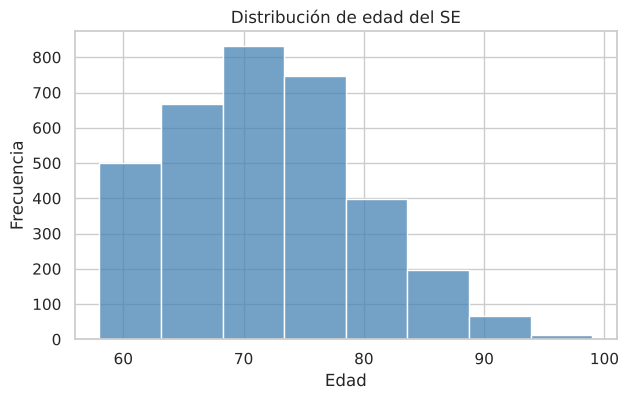

In [10]:
plt.figure(figsize=(7, 4))
sns.histplot(datos_completos["AGE_MXCOG_21"], binwidth=5, color="steelblue")
plt.title(f"Distribución de {etiquetas['AGE_MXCOG_21'].lower()} del SE")
plt.xlabel(etiquetas["AGE_MXCOG_21"])
plt.ylabel("Frecuencia")
plt.show()

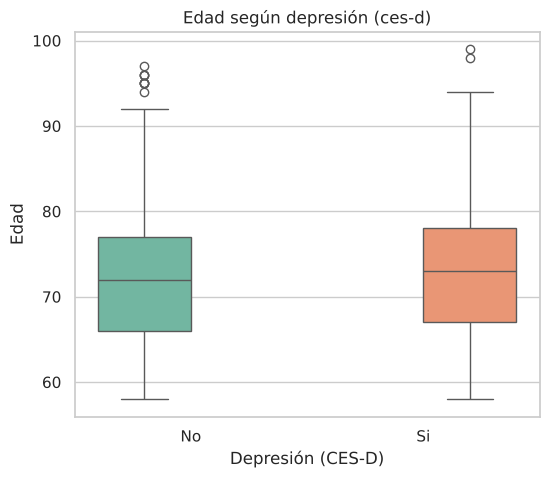

In [11]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=datos_completos, x="MC_CESD_DEPRIMIDO_21", y="AGE_MXCOG_21",
            hue="MC_CESD_DEPRIMIDO_21", palette="Set2", legend=False)
plt.title(f"{etiquetas['AGE_MXCOG_21']} según {etiquetas['MC_CESD_DEPRIMIDO_21'].lower()}")
plt.xlabel(etiquetas["MC_CESD_DEPRIMIDO_21"])
plt.ylabel(etiquetas["AGE_MXCOG_21"])
plt.show()

### 5.3 Tablas cruzadas (predictor vs. depresión)

In [12]:
vars_aivd = ["MC_AIVD_COMIDAS_21", "MC_AIVD_COMPRAR_21", "MC_AIVD_MEDICINA_21", "MC_AIVD_DINERO_21"]
vars_aislamiento = ["MC_AISLADO_21", "MC_IGNORADO_21", "MC_FALTA_COMPA_21"]
vars_categoricas = ["SEX_MXCOG_21"] + vars_aivd + ["MC_COMP_MEMORIA_21"] + vars_aislamiento + ["MC_ESTRES_21"]

for v in vars_categoricas:
    print(f"\n>> {etiquetas[v]} ({v})")
    tab = pd.crosstab(datos_completos[v], datos_completos["MC_CESD_DEPRIMIDO_21"])
    print(tab)
    print(pd.crosstab(datos_completos[v], datos_completos["MC_CESD_DEPRIMIDO_21"], normalize="index").round(3) * 100)


>> Sexo (SEX_MXCOG_21)
MC_CESD_DEPRIMIDO_21    No   Si
SEX_MXCOG_21                   
Hombre                1018  430
Mujer                 1072  898
MC_CESD_DEPRIMIDO_21    No    Si
SEX_MXCOG_21                    
Hombre                70.3  29.7
Mujer                 54.4  45.6

>> Dificultad: preparar comidas (MC_AIVD_COMIDAS_21)
MC_CESD_DEPRIMIDO_21    No    Si
MC_AIVD_COMIDAS_21              
No                    1953  1071
Si                     137   257
MC_CESD_DEPRIMIDO_21    No    Si
MC_AIVD_COMIDAS_21              
No                    64.6  35.4
Si                    34.8  65.2

>> Dificultad: ir de compras (MC_AIVD_COMPRAR_21)
MC_CESD_DEPRIMIDO_21    No   Si
MC_AIVD_COMPRAR_21             
No                    1790  872
Si                     300  456
MC_CESD_DEPRIMIDO_21    No    Si
MC_AIVD_COMPRAR_21              
No                    67.2  32.8
Si                    39.7  60.3

>> Dificultad: tomar medicinas (MC_AIVD_MEDICINA_21)
MC_CESD_DEPRIMIDO_21    No    Si


### 5.4 Gráficos de barras apiladas (proporción de depresión por categoría)



**Depresión según: Sexo**

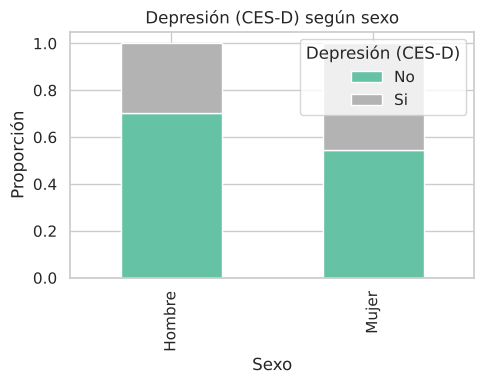

In [13]:
tab = pd.crosstab(datos_completos["SEX_MXCOG_21"], datos_completos["MC_CESD_DEPRIMIDO_21"], normalize="index")
tab.plot(kind="bar", stacked=True, figsize=(5, 4), colormap="Set2")
plt.title(f"{etiquetas['MC_CESD_DEPRIMIDO_21']} según {etiquetas['SEX_MXCOG_21'].lower()}")
plt.ylabel("Proporción")
plt.xlabel(etiquetas["SEX_MXCOG_21"])
plt.legend(title=etiquetas["MC_CESD_DEPRIMIDO_21"])
plt.tight_layout()
plt.show()

**Depresión según: Dificultad: preparar comidas**

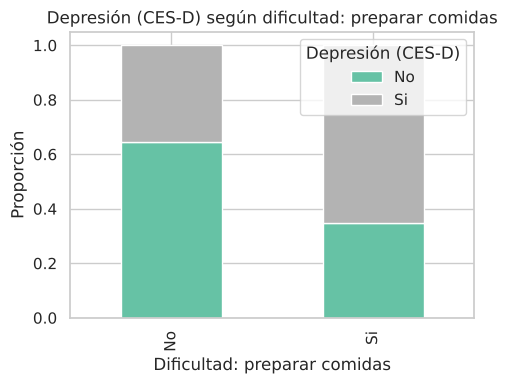

In [14]:
tab = pd.crosstab(datos_completos["MC_AIVD_COMIDAS_21"], datos_completos["MC_CESD_DEPRIMIDO_21"], normalize="index")
tab.plot(kind="bar", stacked=True, figsize=(5, 4), colormap="Set2")
plt.title(f"{etiquetas['MC_CESD_DEPRIMIDO_21']} según {etiquetas['MC_AIVD_COMIDAS_21'].lower()}")
plt.ylabel("Proporción")
plt.xlabel(etiquetas["MC_AIVD_COMIDAS_21"])
plt.legend(title=etiquetas["MC_CESD_DEPRIMIDO_21"])
plt.tight_layout()
plt.show()

**Depresión según: Dificultad: ir de compras**

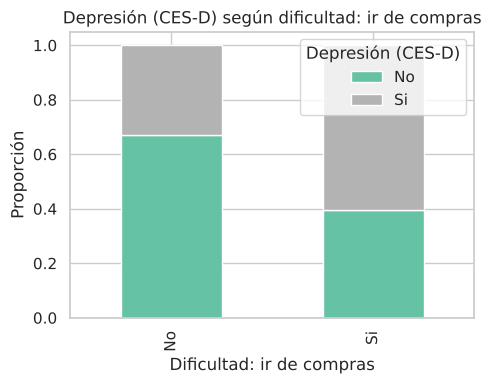

In [15]:
tab = pd.crosstab(datos_completos["MC_AIVD_COMPRAR_21"], datos_completos["MC_CESD_DEPRIMIDO_21"], normalize="index")
tab.plot(kind="bar", stacked=True, figsize=(5, 4), colormap="Set2")
plt.title(f"{etiquetas['MC_CESD_DEPRIMIDO_21']} según {etiquetas['MC_AIVD_COMPRAR_21'].lower()}")
plt.ylabel("Proporción")
plt.xlabel(etiquetas["MC_AIVD_COMPRAR_21"])
plt.legend(title=etiquetas["MC_CESD_DEPRIMIDO_21"])
plt.tight_layout()
plt.show()

**Depresión según: Dificultad: tomar medicinas**

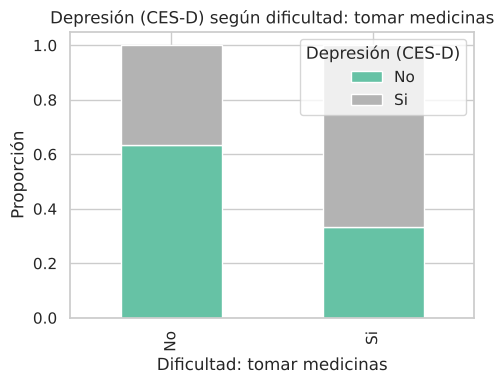

In [16]:
tab = pd.crosstab(datos_completos["MC_AIVD_MEDICINA_21"], datos_completos["MC_CESD_DEPRIMIDO_21"], normalize="index")
tab.plot(kind="bar", stacked=True, figsize=(5, 4), colormap="Set2")
plt.title(f"{etiquetas['MC_CESD_DEPRIMIDO_21']} según {etiquetas['MC_AIVD_MEDICINA_21'].lower()}")
plt.ylabel("Proporción")
plt.xlabel(etiquetas["MC_AIVD_MEDICINA_21"])
plt.legend(title=etiquetas["MC_CESD_DEPRIMIDO_21"])
plt.tight_layout()
plt.show()

**Depresión según: Dificultad: manejar dinero**

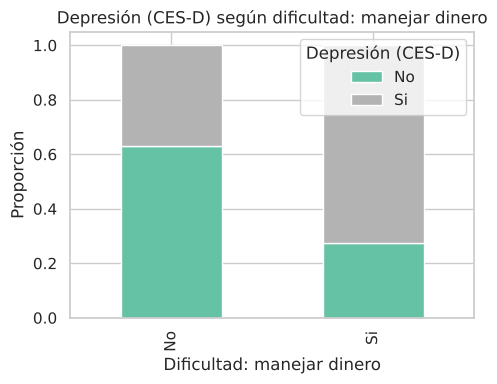

In [17]:
tab = pd.crosstab(datos_completos["MC_AIVD_DINERO_21"], datos_completos["MC_CESD_DEPRIMIDO_21"], normalize="index")
tab.plot(kind="bar", stacked=True, figsize=(5, 4), colormap="Set2")
plt.title(f"{etiquetas['MC_CESD_DEPRIMIDO_21']} según {etiquetas['MC_AIVD_DINERO_21'].lower()}")
plt.ylabel("Proporción")
plt.xlabel(etiquetas["MC_AIVD_DINERO_21"])
plt.legend(title=etiquetas["MC_CESD_DEPRIMIDO_21"])
plt.tight_layout()
plt.show()

**Depresión según: Cambio en la memoria**

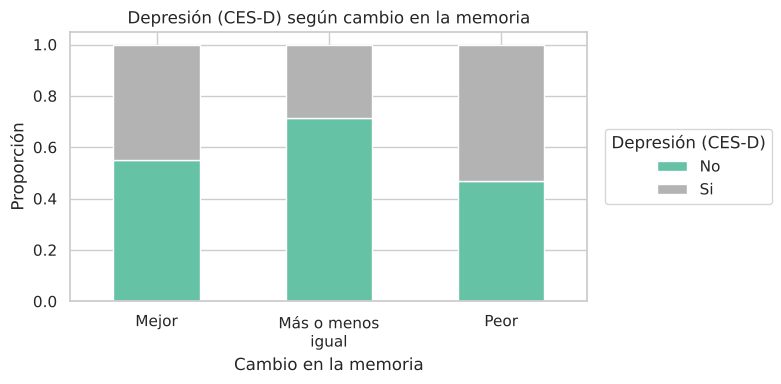

In [18]:
tab = pd.crosstab(datos_completos["MC_COMP_MEMORIA_21"], datos_completos["MC_CESD_DEPRIMIDO_21"], normalize="index")
tab.index = [textwrap.fill(niveles["MC_COMP_MEMORIA_21"][k], 13) for k in tab.index]
tab.plot(kind="bar", stacked=True, figsize=(8, 4), colormap="Set2", rot=0)
plt.title(f"{etiquetas['MC_CESD_DEPRIMIDO_21']} según {etiquetas['MC_COMP_MEMORIA_21'].lower()}")
plt.ylabel("Proporción")
plt.xlabel(etiquetas["MC_COMP_MEMORIA_21"])
plt.legend(title=etiquetas["MC_CESD_DEPRIMIDO_21"], loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

**Depresión según: Se siente aislado**

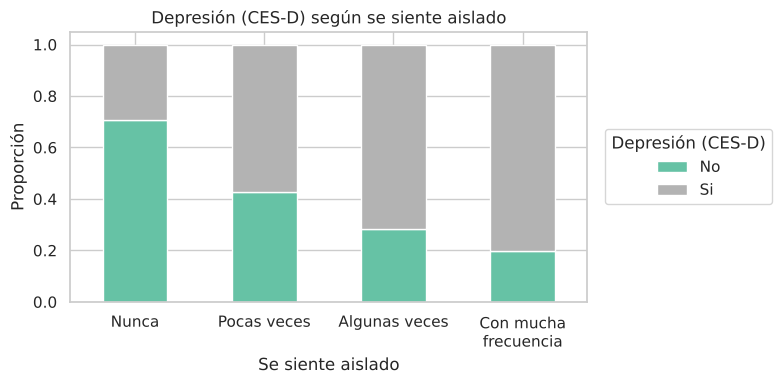

In [19]:
tab = pd.crosstab(datos_completos["MC_AISLADO_21"], datos_completos["MC_CESD_DEPRIMIDO_21"], normalize="index")
tab.index = [textwrap.fill(niveles["MC_AISLADO_21"][k], 13) for k in tab.index]
tab.plot(kind="bar", stacked=True, figsize=(8, 4), colormap="Set2", rot=0)
plt.title(f"{etiquetas['MC_CESD_DEPRIMIDO_21']} según {etiquetas['MC_AISLADO_21'].lower()}")
plt.ylabel("Proporción")
plt.xlabel(etiquetas["MC_AISLADO_21"])
plt.legend(title=etiquetas["MC_CESD_DEPRIMIDO_21"], loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

**Depresión según: Se siente ignorado**

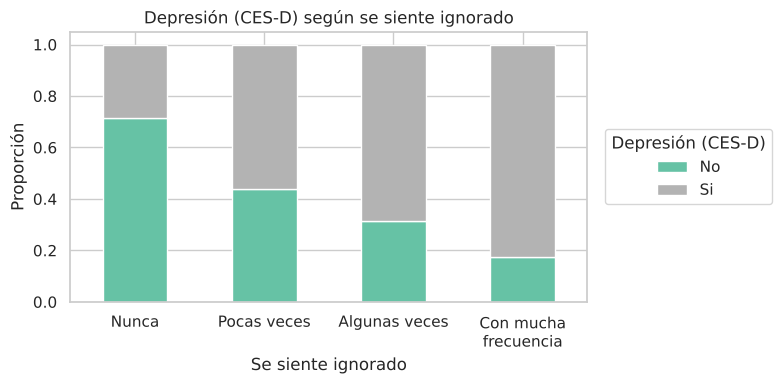

In [20]:
tab = pd.crosstab(datos_completos["MC_IGNORADO_21"], datos_completos["MC_CESD_DEPRIMIDO_21"], normalize="index")
tab.index = [textwrap.fill(niveles["MC_IGNORADO_21"][k], 13) for k in tab.index]
tab.plot(kind="bar", stacked=True, figsize=(8, 4), colormap="Set2", rot=0)
plt.title(f"{etiquetas['MC_CESD_DEPRIMIDO_21']} según {etiquetas['MC_IGNORADO_21'].lower()}")
plt.ylabel("Proporción")
plt.xlabel(etiquetas["MC_IGNORADO_21"])
plt.legend(title=etiquetas["MC_CESD_DEPRIMIDO_21"], loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

**Depresión según: Le falta compañía**

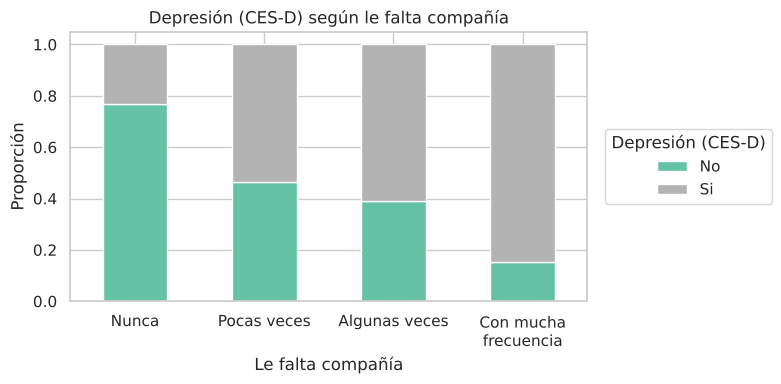

In [21]:
tab = pd.crosstab(datos_completos["MC_FALTA_COMPA_21"], datos_completos["MC_CESD_DEPRIMIDO_21"], normalize="index")
tab.index = [textwrap.fill(niveles["MC_FALTA_COMPA_21"][k], 13) for k in tab.index]
tab.plot(kind="bar", stacked=True, figsize=(8, 4), colormap="Set2", rot=0)
plt.title(f"{etiquetas['MC_CESD_DEPRIMIDO_21']} según {etiquetas['MC_FALTA_COMPA_21'].lower()}")
plt.ylabel("Proporción")
plt.xlabel(etiquetas["MC_FALTA_COMPA_21"])
plt.legend(title=etiquetas["MC_CESD_DEPRIMIDO_21"], loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

**Depresión según: Estrés por la pandemia**

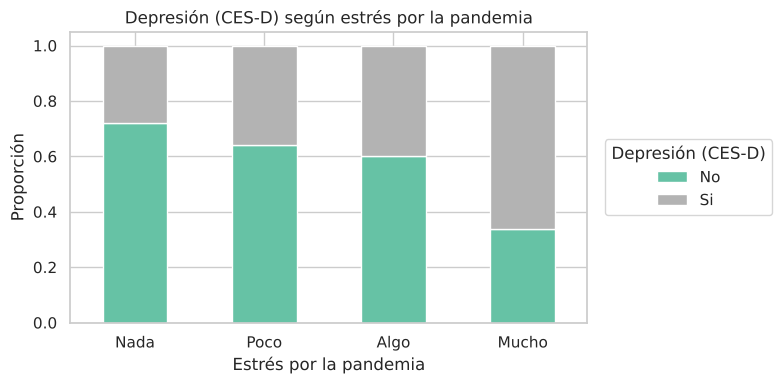

In [22]:
tab = pd.crosstab(datos_completos["MC_ESTRES_21"], datos_completos["MC_CESD_DEPRIMIDO_21"], normalize="index")
tab.index = [textwrap.fill(niveles["MC_ESTRES_21"][k], 13) for k in tab.index]
tab.plot(kind="bar", stacked=True, figsize=(8, 4), colormap="Set2", rot=0)
plt.title(f"{etiquetas['MC_CESD_DEPRIMIDO_21']} según {etiquetas['MC_ESTRES_21'].lower()}")
plt.ylabel("Proporción")
plt.xlabel(etiquetas["MC_ESTRES_21"])
plt.legend(title=etiquetas["MC_CESD_DEPRIMIDO_21"], loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

## 6. División train / test

In [23]:
datos_completos["y"] = (datos_completos["MC_CESD_DEPRIMIDO_21"] == "Si").astype(int)

train, test = train_test_split(
    datos_completos, test_size=0.3, random_state=123, stratify=datos_completos["y"]
)

print("Casos en entrenamiento:", len(train))
print("Casos en prueba:", len(test))

Casos en entrenamiento: 2392
Casos en prueba: 1026


## 7. Ajuste del modelo de regresión logística múltiple

In [24]:
formula = (
    "y ~ AGE_MXCOG_21 + C(SEX_MXCOG_21) + "
    "C(MC_AIVD_COMIDAS_21) + C(MC_AIVD_COMPRAR_21) + C(MC_AIVD_MEDICINA_21) + C(MC_AIVD_DINERO_21) + "
    "C(MC_COMP_MEMORIA_21) + C(MC_AISLADO_21) + C(MC_IGNORADO_21) + C(MC_FALTA_COMPA_21) + C(MC_ESTRES_21)"
)

modelo_logistico = smf.glm(formula=formula, data=train, family=sm.families.Binomial()).fit()
print(modelo_logistico.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 2392
Model:                            GLM   Df Residuals:                     2371
Model Family:                Binomial   Df Model:                           20
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1236.8
Date:                Sat, 03 Oct 2026   Deviance:                       2473.7
Time:                        17:41:31   Pearson chi2:                 2.36e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2606
Covariance Type:            nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

## 8. Odds Ratios e intervalos de confianza

In [25]:
ic = modelo_logistico.conf_int()
tabla_or = pd.DataFrame({
    "OR": np.exp(modelo_logistico.params),
    "IC_2.5": np.exp(ic[0]),
    "IC_97.5": np.exp(ic[1]),
    "p_valor": modelo_logistico.pvalues,
}).round(3)

# Columna con nombre legible para reportes
tabla_or.insert(0, "Variable", [etiqueta_amigable(t) for t in tabla_or.index])
tabla_or

,Variable,OR,IC_2.5,IC_97.5,p_valor
Intercept,Intercepto,0.112,0.035,0.353,0.000
C(SEX_MXCOG_21)[T.Mujer],Sexo: Mujer,1.295,1.057,1.586,0.013
C(MC_AIVD_COMIDAS_21)[T.Si],Dificultad: preparar comidas: Si,1.335,0.934,1.907,0.113
C(MC_AIVD_COMPRAR_21)[T.Si],Dificultad: ir de compras: Si,1.616,1.234,2.116,0.000
C(MC_AIVD_MEDICINA_21)[T.Si],Dificultad: tomar medicinas: Si,1.417,0.930,2.161,0.105
C(MC_AIVD_DINERO_21)[T.Si],Dificultad: manejar dinero: Si,1.847,1.150,2.966,0.011
C(MC_COMP_MEMORIA_21)[T.2],Cambio en la memoria: Más o menos igual,0.505,0.291,0.876,0.015
C(MC_COMP_MEMORIA_21)[T.3],Cambio en la memoria: Peor,1.128,0.648,1.966,0.670
C(MC_AISLADO_21)[T.2],Se siente aislado: Pocas veces,1.065,0.777,1.461,0.695
C(MC_AISLADO_21)[T.3],Se siente aislado: Algunas veces,1.945,1.231,3.072,0.004


## 9. Diagnóstico del modelo

### 9.1 Multicolinealidad (VIF)

In [26]:
predictores = ["AGE_MXCOG_21", "SEX_MXCOG_21"] + vars_aivd + \
    ["MC_COMP_MEMORIA_21"] + vars_aislamiento + ["MC_ESTRES_21"]

X_design = pd.get_dummies(train[predictores], drop_first=True).astype(float)
X_design = sm.add_constant(X_design)

vif_data = pd.DataFrame()
vif_data["Variable"] = [etiqueta_dummy(c) for c in X_design.columns]
vif_data["VIF"] = [variance_inflation_factor(X_design.values, i) for i in range(X_design.shape[1])]
vif_data.round(2)

,Variable,VIF
0,Constante,1.00
1,Edad,1.10
2,Sexo: Mujer,1.08
3,Dificultad: preparar comidas: Si,1.42
4,Dificultad: ir de compras: Si,1.46
5,Dificultad: tomar medicinas: Si,1.21
6,Dificultad: manejar dinero: Si,1.25
7,Cambio en la memoria: Más o menos igual,8.67
8,Cambio en la memoria: Peor,8.66
9,Se siente aislado: Pocas veces,1.59


### 9.2 Bondad de ajuste (Hosmer-Lemeshow)

In [27]:
def hosmer_lemeshow(y_true, y_prob, g=10):
    data = pd.DataFrame({"y": y_true.values, "prob": y_prob.values})
    data["decil"] = pd.qcut(data["prob"], g, duplicates="drop")
    grp = data.groupby("decil", observed=True)

    obs_1 = grp["y"].sum()
    obs_0 = grp["y"].count() - obs_1
    exp_1 = grp["prob"].sum()
    exp_0 = grp["prob"].count() - exp_1

    hl_stat = (((obs_1 - exp_1) ** 2 / exp_1) + ((obs_0 - exp_0) ** 2 / exp_0)).sum()
    dof = len(grp) - 2
    p_valor = 1 - chi2.cdf(hl_stat, dof)
    return hl_stat, p_valor


prob_train = modelo_logistico.predict(train)
hl_stat, hl_p = hosmer_lemeshow(train["y"], prob_train, g=10)
print(f"Estadístico Hosmer-Lemeshow: {hl_stat:.4f}")
print(f"p-valor: {hl_p:.4f}")
print("(p > 0.05 sugiere buen ajuste: no hay evidencia de falta de ajuste)")

Estadístico Hosmer-Lemeshow: 10.7179
p-valor: 0.2182
(p > 0.05 sugiere buen ajuste: no hay evidencia de falta de ajuste)


### 9.3 Observaciones influyentes (distancia de Cook)

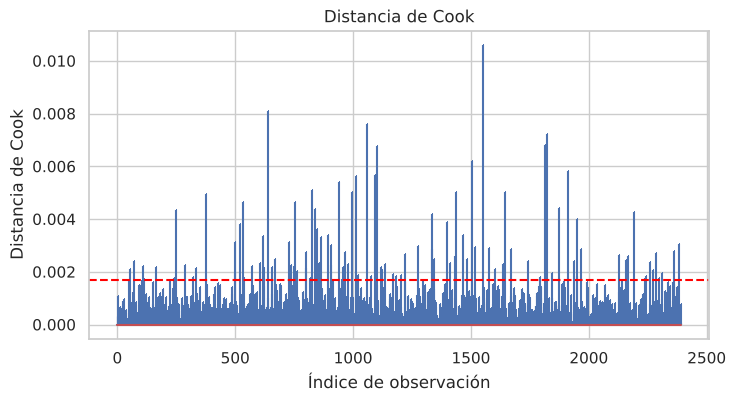

Distancia de Cook máxima: 0.0106
Umbral de referencia (4/n): 0.0017


In [28]:
influencia = modelo_logistico.get_influence()
cooks_d = influencia.cooks_distance[0]

plt.figure(figsize=(8, 4))
plt.stem(cooks_d, markerfmt=",")
umbral_cook = 4 / len(train)
plt.axhline(y=umbral_cook, color="red", linestyle="--")
plt.title("Distancia de Cook")
plt.xlabel("Índice de observación")
plt.ylabel("Distancia de Cook")
plt.show()

print(f"Distancia de Cook máxima: {cooks_d.max():.4f}")
print(f"Umbral de referencia (4/n): {umbral_cook:.4f}")


## 10. Evaluación sobre el conjunto de prueba

In [29]:
probabilidades_test = modelo_logistico.predict(test)

auc_valor = roc_auc_score(test["y"], probabilidades_test)
print(f"AUC en el conjunto de prueba: {auc_valor:.4f}")

fpr, tpr, thresholds = roc_curve(test["y"], probabilidades_test)

AUC en el conjunto de prueba: 0.8329


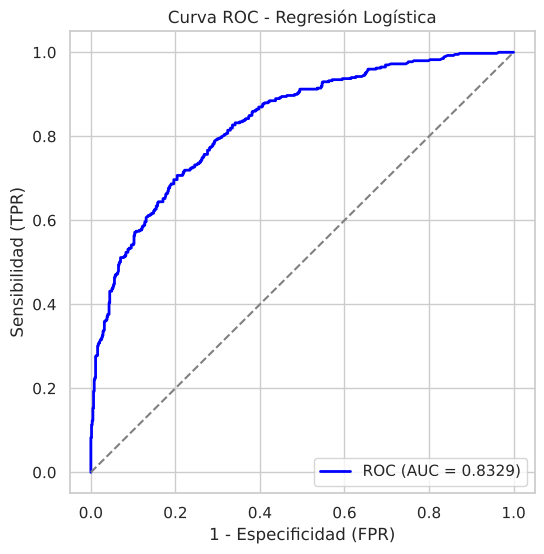

In [30]:
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC (AUC = {auc_valor:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("1 - Especificidad (FPR)")
plt.ylabel("Sensibilidad (TPR)")
plt.title("Curva ROC - Regresión Logística")
plt.legend(loc="lower right")
plt.show()

### Punto de corte óptimo (criterio de Youden)

In [31]:
youden = tpr - fpr
idx_best = np.argmax(youden)
umbral_optimo = thresholds[idx_best]

print(f"Umbral óptimo (Youden): {umbral_optimo:.4f}")
print(f"Sensibilidad en ese punto: {tpr[idx_best]:.3f}")
print(f"Especificidad en ese punto: {1 - fpr[idx_best]:.3f}")

Umbral óptimo (Youden): 0.4165
Sensibilidad en ese punto: 0.707
Especificidad en ese punto: 0.796


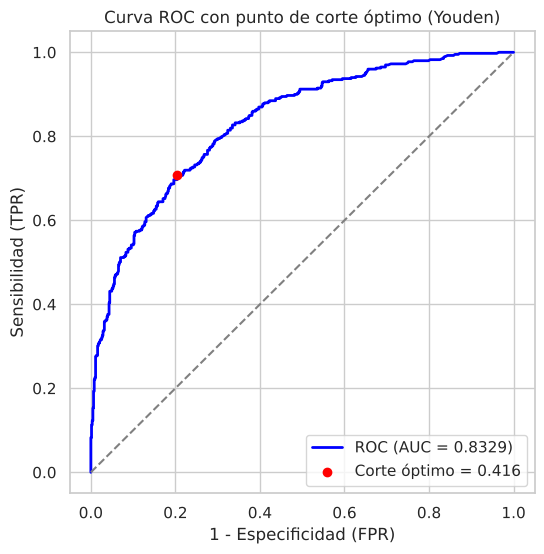

In [32]:
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC (AUC = {auc_valor:.4f})")
plt.scatter(fpr[idx_best], tpr[idx_best], color="red", zorder=5,
            label=f"Corte óptimo = {umbral_optimo:.3f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("1 - Especificidad (FPR)")
plt.ylabel("Sensibilidad (TPR)")
plt.title("Curva ROC con punto de corte óptimo (Youden)")
plt.legend(loc="lower right")
plt.show()

## 11. Clasificación y matriz de confusión

Matriz de Confusión (umbral = 0.4165):
[[499 128]
 [117 282]]


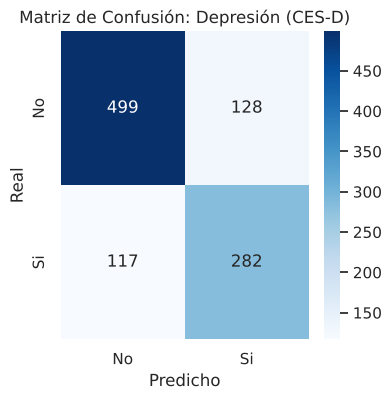

In [33]:
# Se usa el punto de corte óptimo de Youden calculado en la sección 10
umbral = umbral_optimo
pred_clase = (probabilidades_test >= umbral).astype(int)

matriz_confusion = confusion_matrix(test["y"], pred_clase)
print(f"Matriz de Confusión (umbral = {umbral:.4f}):")
print(matriz_confusion)

plt.figure(figsize=(4, 4))
sns.heatmap(matriz_confusion, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No", "Si"], yticklabels=["No", "Si"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title(f"Matriz de Confusión: {etiquetas['MC_CESD_DEPRIMIDO_21']}")
plt.show()

In [34]:
tn, fp, fn, tp = matriz_confusion.ravel()

exactitud = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
sensibilidad = tp / (tp + fn)
especificidad = tn / (tn + fp)
f1 = 2 * precision * sensibilidad / (precision + sensibilidad)

print(f"Exactitud (accuracy): {exactitud * 100:.2f}%")
print(f"Precisión: {precision * 100:.2f}%")
print(f"Sensibilidad (recall): {sensibilidad * 100:.2f}%")
print(f"Especificidad: {especificidad * 100:.2f}%")
print(f"F1-score: {f1 * 100:.2f}%")

Exactitud (accuracy): 76.12%
Precisión: 68.78%
Sensibilidad (recall): 70.68%
Especificidad: 79.59%
F1-score: 69.72%


## 12. Gráfica de razones de momios

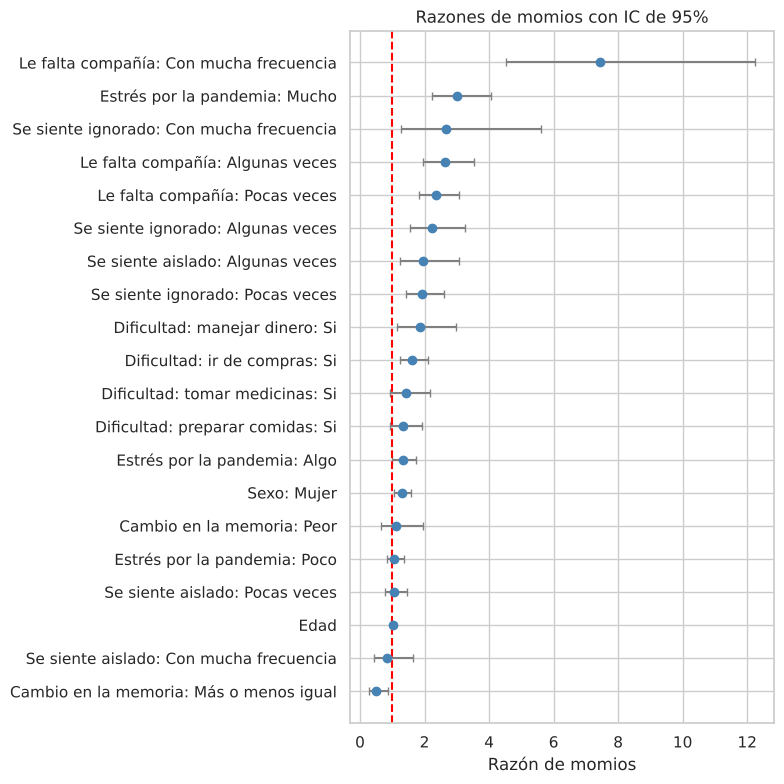

In [35]:
tabla_or_plot = tabla_or.drop(index="Intercept").reset_index(drop=True)
tabla_or_plot = tabla_or_plot.sort_values("OR")

plt.figure(figsize=(8, 8))
plt.errorbar(
    tabla_or_plot["OR"], range(len(tabla_or_plot)),
    xerr=[tabla_or_plot["OR"] - tabla_or_plot["IC_2.5"],
          tabla_or_plot["IC_97.5"] - tabla_or_plot["OR"]],
    fmt="o", color="steelblue", ecolor="gray", capsize=3
)
plt.axvline(x=1, color="red", linestyle="--")
plt.yticks(range(len(tabla_or_plot)), tabla_or_plot["Variable"])
plt.xlabel("Razón de momios")
plt.title("Razones de momios con IC de 95%")
plt.tight_layout()
plt.show()